In [1]:
import matplotlib.pyplot as plt
#from src.TimeSeriesAnalysis import *
#from src.process_data import summarize_all_dirs, create_folder, process_all_data
from IPython.display import clear_output
from src.TimeSeriesAnalysis import detect_equilibrium_start_with_errors, weighted_mean_and_sem, idx_from_t0, read_mean_json, select_random_json, read_experiment_json, create_folder
plt.style.use('properties.mplstyle')
from matplotlib.ticker import AutoMinorLocator, MultipleLocator, LinearLocator,FormatStrFormatter
from matplotlib.lines import Line2D
#from src.process_data import process_all_roots, summarize_all_dirs
from IPython.display import clear_output
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

from tqdm import tqdm
import pandas as pd
import os
import numpy as np

In [2]:
results = "../results/parameters_effects"
create_folder(results)

In [3]:
df = pd.read_csv("../SOP_data/all_data.dat", sep=' ')
df = df.dropna()
df = df[df['N_samples']==df['N_samples_perc']]
df

,type_perc,dim,L,f_T,c,nc,rho,p0,P0,order,N_samples,N_samples_perc,p_mean,p_err,shortest_path,shortest_path_err,S_perc,S_perc_err
33,bond,3,768,0.006710,0.01,1,1.000,0.6,0.1,1,10,10,0.249808,0.000003,6262.40,273.644506,4.554752e+07,1.081797e+06
34,bond,3,1024,0.006710,0.01,1,1.000,0.6,0.1,1,5,5,0.249260,0.000002,8696.80,431.721600,9.809558e+07,3.061865e+06
41,bond,3,1024,0.007229,0.01,1,1.000,0.6,0.1,1,5,5,0.249343,0.000002,8330.60,340.426732,1.000673e+08,2.581193e+06
48,bond,3,1024,0.007748,0.01,1,1.000,0.6,0.1,1,5,5,0.249448,0.000002,8206.40,331.181763,1.035959e+08,2.676646e+06
52,bond,3,512,0.008267,0.01,1,1.000,0.6,0.1,1,25,25,0.249828,0.000004,3847.84,116.186469,1.755755e+07,2.491502e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16920,bond,3,384,0.162958,0.50,8,0.125,0.6,0.1,6,52,52,1.000000,0.000000,383.00,0.000000,7.184269e+04,1.939077e+03
16921,bond,3,384,0.162958,0.50,8,0.125,0.6,0.1,7,52,52,1.000000,0.000000,383.00,0.000000,7.188169e+04,2.066440e+03
16922,bond,3,384,0.162958,0.50,8,0.125,0.6,0.1,8,52,52,1.000000,0.000000,383.00,0.000000,7.524896e+04,2.301396e+03
16923,node,3,16,0.060000,0.01,1,1.000,1.0,0.1,1,3,3,0.993478,0.000044,15.00,0.000000,3.385000e+03,2.487971e+01


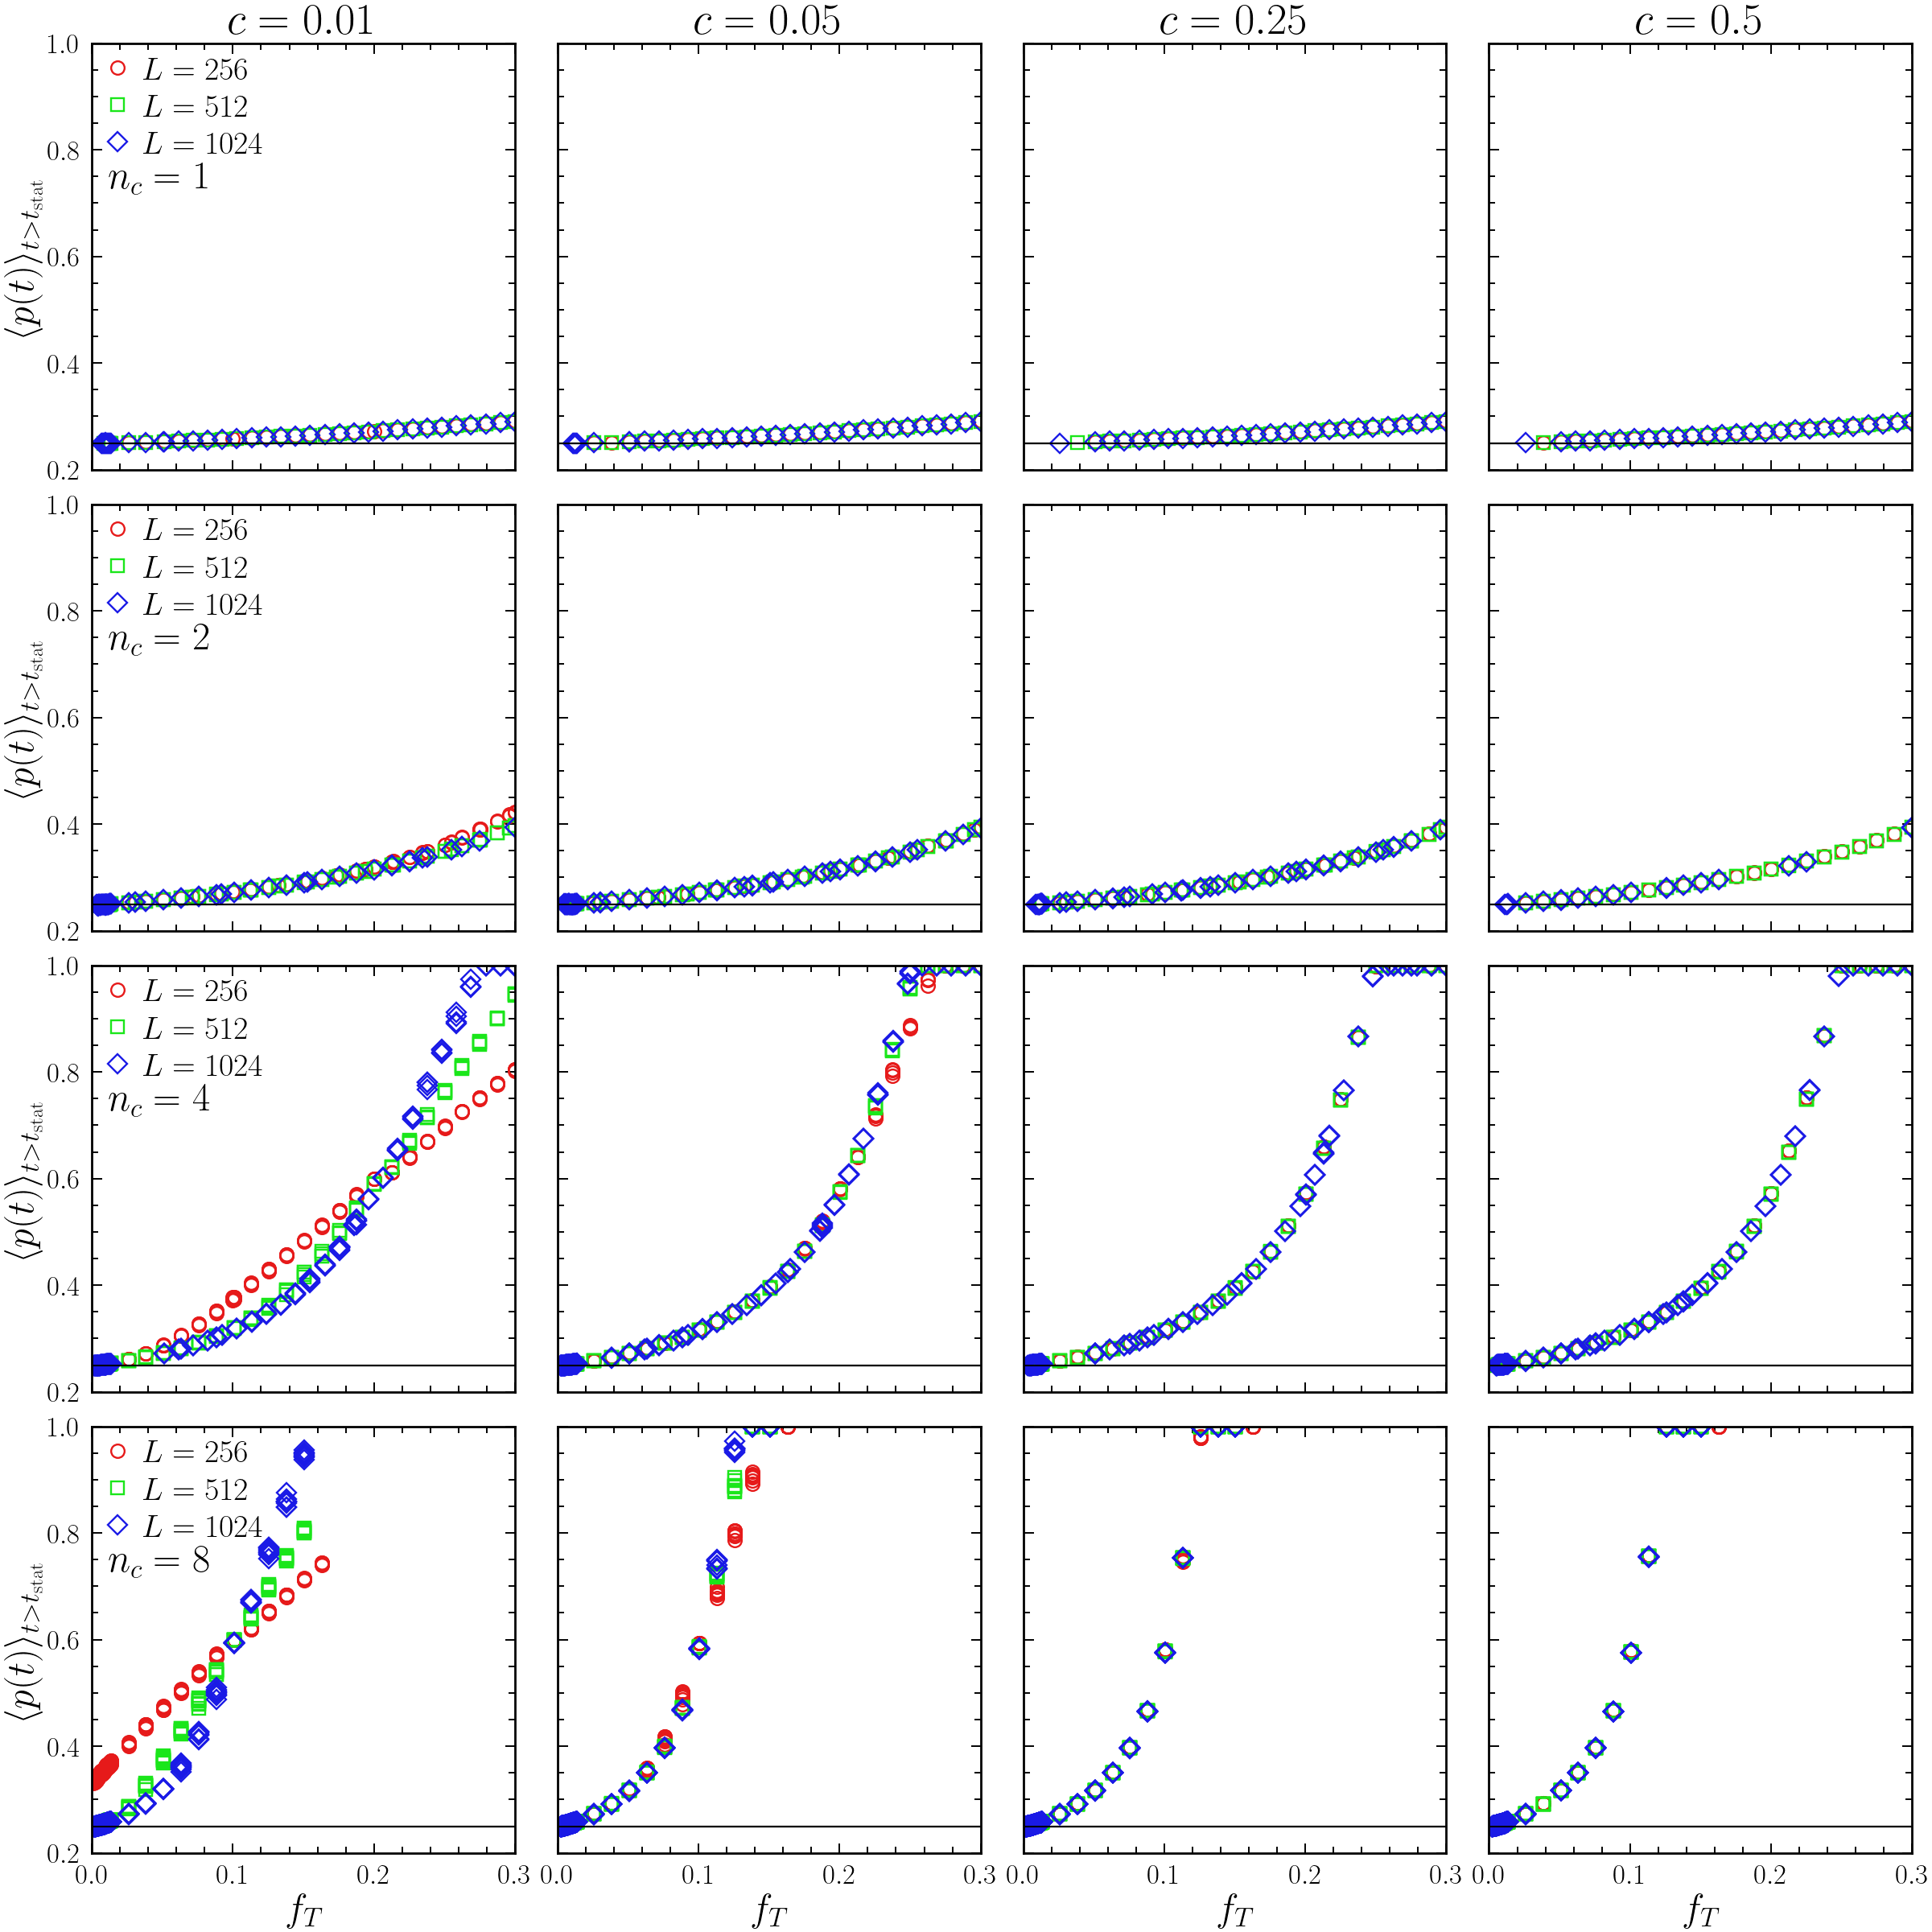

In [9]:
#L_lst = [256, 512, 1024]
L_lst = [256, 512, 1024]
c_lst = [0.01, 0.05, 0.25, 0.50]
nc_lst = [1, 2, 4, 8]
p0 = 0.6
P0 = 0.1

base = 6
#fig, axes = plt.subplots(1, len(c_lst), figsize=(4*base, 1*base), constrained_layout=True, sharey=True)
fig, axes = plt.subplots(len(nc_lst), len(c_lst), figsize=(len(c_lst)*base, len(nc_lst)*base), constrained_layout=True, sharey=True, sharex=True)
markers = ['o', 's', 'D']

mew = 1.7
pc = 0.24881182
fs_l_fig = 35
fs_legend = 29
fs_title = 40
tick_size = 20
tick_label_size = 25
labels_size = 35
ms = 12

for idx_nc, nc in enumerate(nc_lst):
    for idx_c, c in enumerate(c_lst):
        for idx, L in enumerate(L_lst):
            ax = axes[idx_nc, idx_c]
            df_b = df[(df['nc']==nc) & (df['L']==L) & (df['c']==c) & (df['type_perc']=='bond') & (df['p0']==p0) & (df['P0']==P0)].sort_values('f_T')
            f_t = df_b['f_T']
            pmean = df_b['p_mean']
            ax.plot(f_t, pmean, marker=markers[idx],ms=ms, mew = mew, ls='None', label=f'$L={L}$')
            ax.axhline(pc, color='k', ls='solid')
            
        if(idx_c==0):
            ax.text(0.04, 0.66, f'$n_c = {nc}$', transform=ax.transAxes , fontsize=fs_l_fig)
            ax.set_ylabel(r'$\langle p(t) \rangle_{t>t_\mathrm{stat}}$', fontsize=labels_size)
            ax.legend(fontsize=fs_legend,loc='upper left', frameon=False)
        if idx_nc==0:
            ax.set_title(f'$c={c}$', fontsize=fs_title)
        if(idx_nc==len(nc_lst)-1):
            
            ax.set_xlim(0, 0.5)
            ax.set_ylim(0.2, 1.0)
            ax.set_xlabel(r'$f_T$', fontsize=labels_size)
        ax.tick_params(axis='both', which='major', labelsize=tick_label_size, pad=10)
        ax.tick_params(axis='both', which='minor', labelsize=tick_label_size, pad=10)
        ax.tick_params(axis='x', which='minor', pad=6)
        ax.tick_params(axis='y', which='minor', pad=6)
        ax.set_xlim(0, 0.3)
#plt.savefig(f"{results}/p_mean_vs_f_T.png", dpi=300)
plt.show()

In [7]:
import numpy as np
import pandas as pd

L_lst = [256, 512, 1024]
c_lst = [0.01, 0.05, 0.25, 0.50]
nc_lst = [1, 2, 4, 8]
p0 = 0.6
P0 = 0.1

df_sub = df[
    (df["nc"].isin(nc_lst)) &
    (df["L"].isin(L_lst)) &
    (df["c"].isin(c_lst)) &
    (df["type_perc"] == "bond") &
    (df["p0"] == p0) &
    (df["P0"] == P0)
].copy()

# Evita problemas de comparação entre floats
df_sub["f_T_round"] = df_sub["f_T"].round(12)

df_min_common = (
    df_sub
    .groupby(["nc", "c", "f_T_round"])["L"]
    .nunique()
    .reset_index(name="n_L")
)

df_min_common = (
    df_min_common[df_min_common["n_L"] == len(L_lst)]
    .groupby(["nc", "c"])["f_T_round"]
    .min()
    .reset_index()
    .rename(columns={"f_T_round": "f_T_min_common"})
)

df_min_common

,nc,c,f_T_min_common
0,1,0.01,0.025917
1,1,0.05,0.025917
2,1,0.25,0.051000
3,1,0.50,0.051000
4,2,0.01,0.006710
5,2,0.05,0.009306
6,2,0.25,0.025917
7,2,0.50,0.025917
8,4,0.01,0.004115
9,4,0.05,0.008786


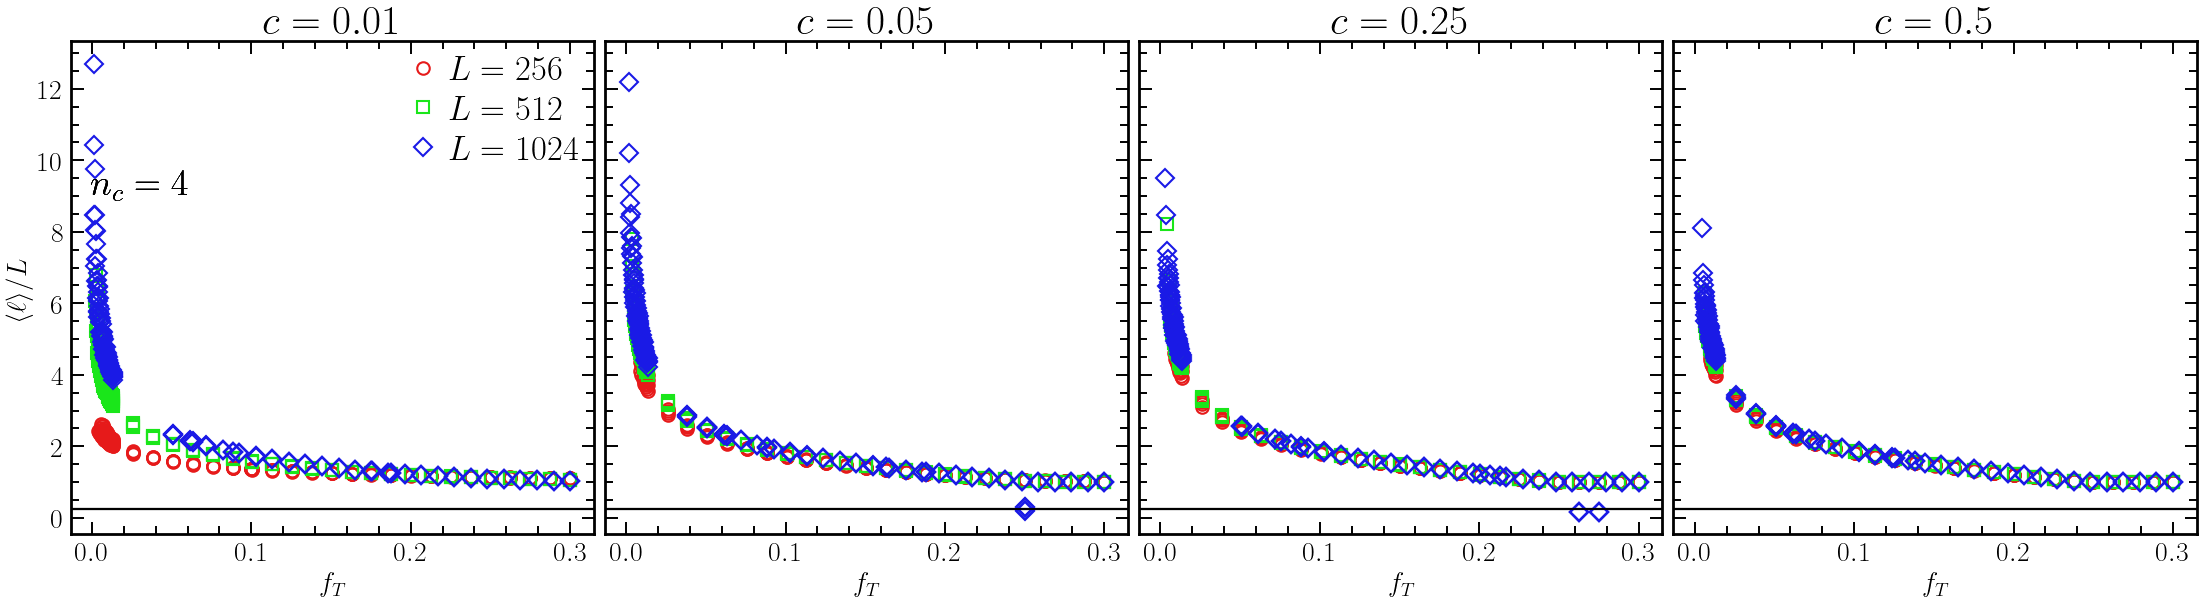

In [14]:
L_lst = [256, 512, 1024]
c_lst = [0.01, 0.05, 0.25, 0.50]
nc = 4
p0 = 0.6
P0 = 0.1

base = 10
#fig, axes = plt.subplots(1, len(c_lst), figsize=(4*base, 1*base), constrained_layout=True, sharey=True)
fig, axes = plt.subplots(1, len(c_lst), figsize=(22, 6), constrained_layout=True, sharey=True, sharex=True)
markers = ['o', 's', 'D']
fs_legend = 25
fs_title = 30
mew = 1.5
pc = 0.24881182
fs_l_fig = 27
for c in c_lst:
    for idx, L in enumerate(L_lst):
        ax = axes[c_lst.index(c)]
        df_b = df[(df['nc']==nc) & (df['L']==L) & (df['c']==c) & (df['type_perc']=='bond') & (df['p0']==p0) & (df['P0']==P0)].sort_values('f_T')
        f_t = df_b['f_T'] 
        pmean = df_b['shortest_path'] / L
        ax.plot(f_t, pmean, marker=markers[idx],mew = mew, ls='None', label=f'$L={L}$' )
        ax.axhline(pc, color='k', ls='solid')
        ax.set_title(f'$c={c}$', fontsize=fs_title)
        
        if(ax==axes[0]):
            ax.set_ylabel(r'$\langle \ell \rangle/L$')
            ax.legend(fontsize=fs_legend)
            ax.text(0.04, 0.69, f'$n_c = {nc}$', transform=ax.transAxes , fontsize=fs_l_fig)
        ax.set_xlabel(r'$f_T$')
plt.show()

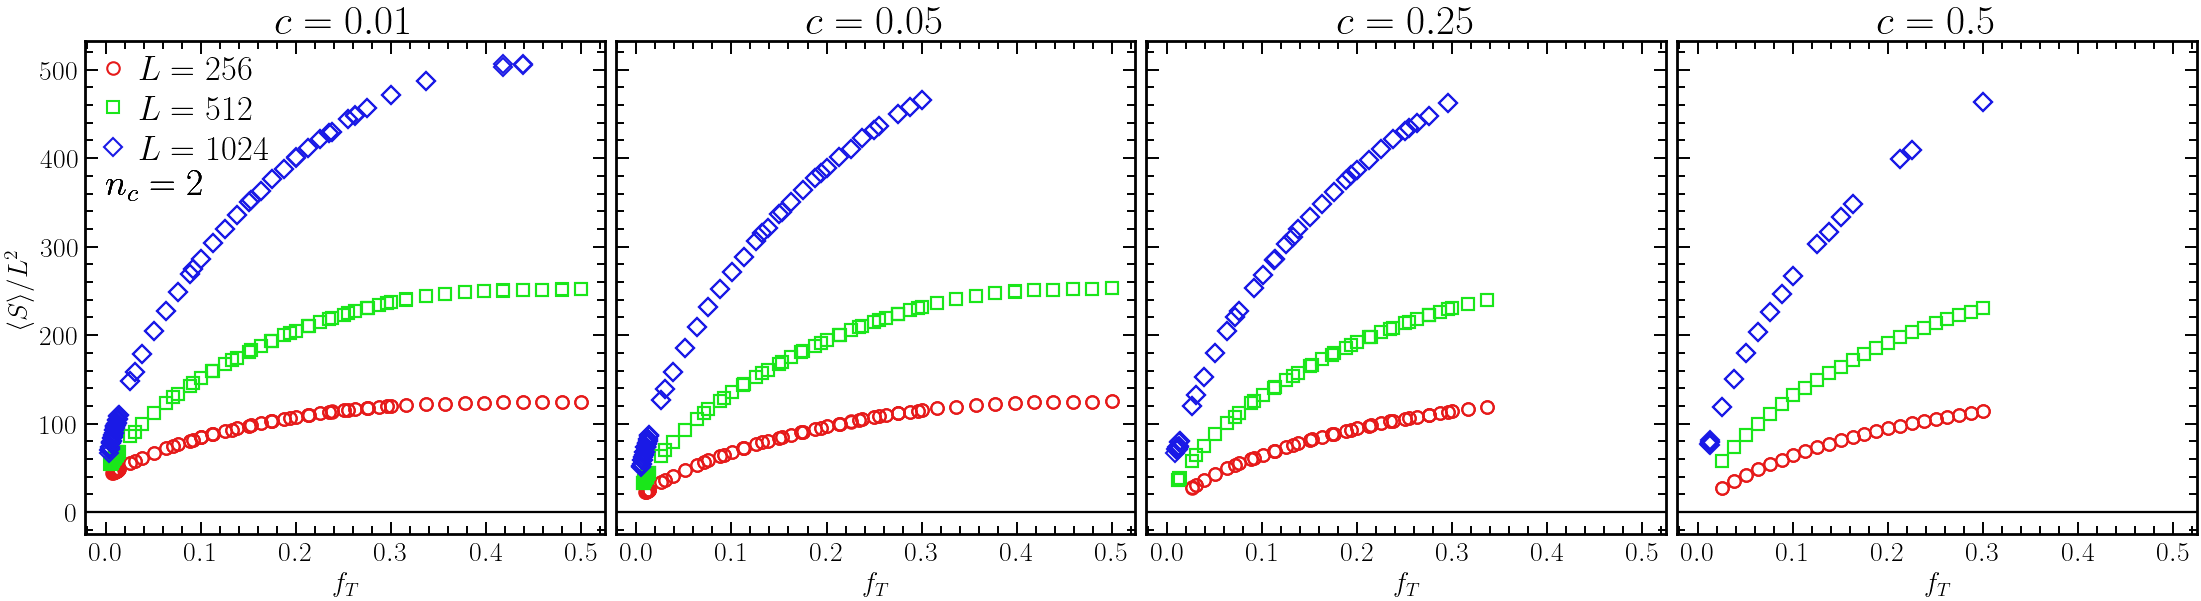

In [16]:
L_lst = [256, 512, 1024]
c_lst = [0.01, 0.05, 0.25, 0.50]
nc = 2
p0 = 0.6
P0 = 0.1

base = 10
#fig, axes = plt.subplots(1, len(c_lst), figsize=(4*base, 1*base), constrained_layout=True, sharey=True)
fig, axes = plt.subplots(1, len(c_lst), figsize=(22, 6), constrained_layout=True, sharey=True, sharex=True)
markers = ['o', 's', 'D']
fs_legend = 25
fs_title = 30
mew = 1.5
pc = 0.24881182
fs_l_fig = 27
for c in c_lst:
    for idx, L in enumerate(L_lst):
        ax = axes[c_lst.index(c)]
        df_b = df[(df['nc']==nc) & (df['L']==L) & (df['c']==c) & (df['type_perc']=='bond') & (df['p0']==p0) & (df['P0']==P0)].sort_values('f_T')
        f_t = df_b['f_T']
        pmean = df_b['S_perc'] / L**2
        ax.plot(f_t, pmean, marker=markers[idx],mew = mew, ls='None', label=f'$L={L}$' )
        ax.axhline(pc, color='k', ls='solid')
        ax.set_title(f'$c={c}$', fontsize=fs_title)
        
        if(ax==axes[0]):
            ax.set_ylabel(r'$\langle S \rangle/L^2$')
            ax.legend(fontsize=fs_legend)
            ax.text(0.04, 0.69, f'$n_c = {nc}$', transform=ax.transAxes , fontsize=fs_l_fig)
        ax.set_xlabel(r'$f_T$')
plt.show()